In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
files = os.listdir('../data/')
print("Fichiers dans data :", files)

Fichiers dans data : ['ssense_dataset.csv']


In [5]:
df = pd.read_csv('../data/ssense_dataset.csv')
print(f"{df.shape[0]}produits et {df.shape[1]}colonnes")
print("\nColonnes :", df.columns.tolist())
df.head()

19919produits et 4colonnes

Colonnes : ['brand', 'description', 'price_usd', 'type']


,brand,description,price_usd,type
0,Rick Owens,Black Moncler Edition Down Coat,2585,mens
1,Rick Owens,Black Moncler Edition Cyclopic Down Coat,2405,mens
2,Rick Owens,Black Moncler Edition Cyclopic Down Jacket,3160,mens
3,Rick Owens,Taupe & Green Moncler Edition Down Coat,3505,mens
4,Rick Owens,Taupe & Green Moncler Edition Cyclopic Down Ja...,2885,mens


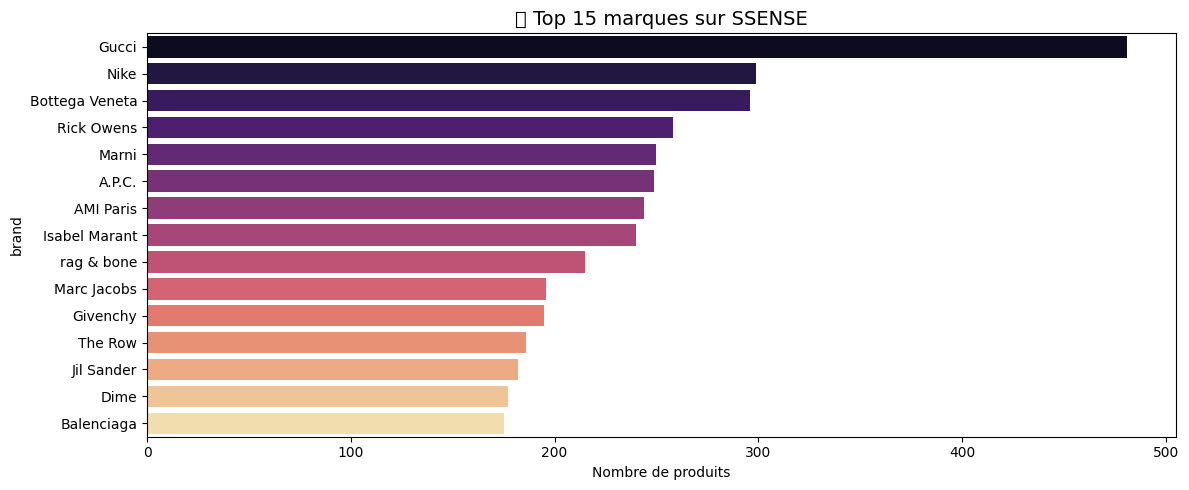

In [6]:
# Top marques
plt.figure(figsize=(12,5))
top_brands = df['brand'].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')
plt.title('🖤 Top 15 marques sur SSENSE', fontsize=14)
plt.xlabel('Nombre de produits')
plt.tight_layout()
plt.savefig('../visuals/top_marques.png')
plt.show()

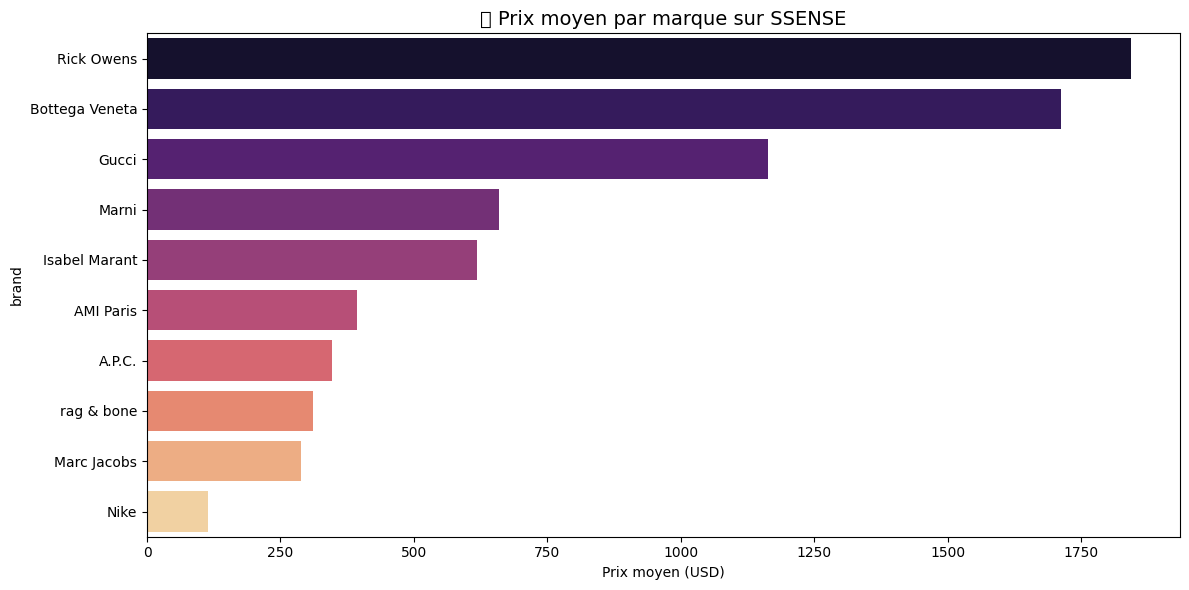


Prix moyen par marque :
brand
Rick Owens        1843.0
Bottega Veneta    1712.0
Gucci             1164.0
Marni              660.0
Isabel Marant      619.0
AMI Paris          393.0
A.P.C.             346.0
rag & bone         311.0
Marc Jacobs        288.0
Nike               114.0
Name: price_usd, dtype: float64


In [9]:
# Prix moyen par marque
plt.figure(figsize=(12,6))
top_brand_names = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brand_names)]

prix_moyen = df_top.groupby('brand')['price_usd'].mean().sort_values(ascending=False)

sns.barplot(x=prix_moyen.values, y=prix_moyen.index, palette='magma')
plt.title('Prix moyen par marque sur SSENSE', fontsize=14)
plt.xlabel('Prix moyen (USD)')
plt.tight_layout()
plt.savefig('../visuals/prix_par_marque.png')
plt.show()

print("\nPrix moyen par marque :")
print(prix_moyen.round(0))

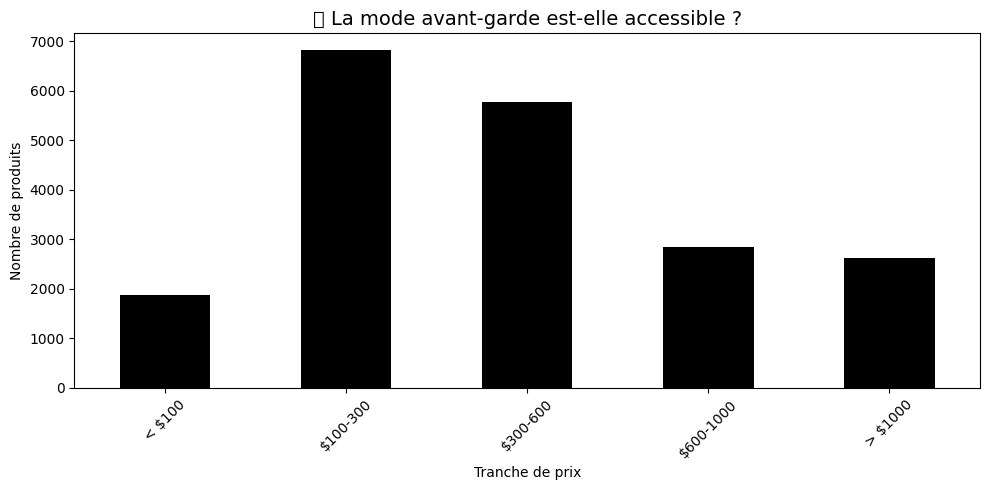

In [8]:
# Accessibilité
bins = [0, 100, 300, 600, 1000, 10000]
labels = ['< $100', '$100-300', '$300-600', '$600-1000', '> $1000']
df['tranche_prix'] = pd.cut(df['price_usd'], bins=bins, labels=labels)

plt.figure(figsize=(10,5))
df['tranche_prix'].value_counts().sort_index().plot(kind='bar', color='black')
plt.title('💀 La mode avant-garde est-elle accessible ?', fontsize=14)
plt.xlabel('Tranche de prix')
plt.ylabel('Nombre de produits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/accessibilite.png')
plt.show()